**Nama:** Selva Tri Martadinata

**NPM:** 25083010008

**Kelas:** Analisis Numerik / A

**Link GitHub:** https://github.com/selvatrimarta80-cpu/Analisis_Numerik_Donat_Selva

## **Perhitungan Volume Lambung Kapal dengan Metode Numerik**

Menentukan perkiraan volume satu lambung kapal dan total volume dua lambung kapal menggunakan metode numerik, yaitu metode trapesium dan metode Simpson 1/3, berdasarkan data lebar dan tinggi penampang pada beberapa titik pengukuran.

## Dasar dan Asumsi Perhitungan

Dalam perhitungan volume lambung kapal, digunakan ketentuan sebagai berikut:

1. Satu kotak grid penuh pada gambar mewakili jarak sebesar 45 cm atau 0,45 m.
2. Lantai kapal dianggap datar atau tidak memiliki lunas (*keel*).
3. Penampang melintang kapal dianggap berbentuk persegi panjang.
4. Volume cadangan daya apung (*reserve buoyancy*) tidak dihitung.
5. Perhitungan dilakukan untuk satu lambung kapal terlebih dahulu, kemudian hasilnya digunakan untuk menentukan total volume dua lambung kapal apabila kedua lambung dianggap memiliki ukuran yang sama.
6. Perhitungan dilakukan menggunakan satuan meter agar volume yang diperoleh dinyatakan dalam meter kubik (m³).

Skala pengukuran yang digunakan adalah:

$$
1\text{ kotak grid} = 45\text{ cm} = 0{,}45\text{ m}
$$

Dengan demikian, setiap jarak satu kotak grid penuh di sepanjang lambung kapal setara dengan 0,45 meter. Ukuran lebar dan tinggi penampang juga perlu diukur dari gambar dan dikonversi ke meter sebelum digunakan dalam perhitungan.



## **1. Import Library dan Menampilkan gambar**

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Kapal.png to Kapal (1).png


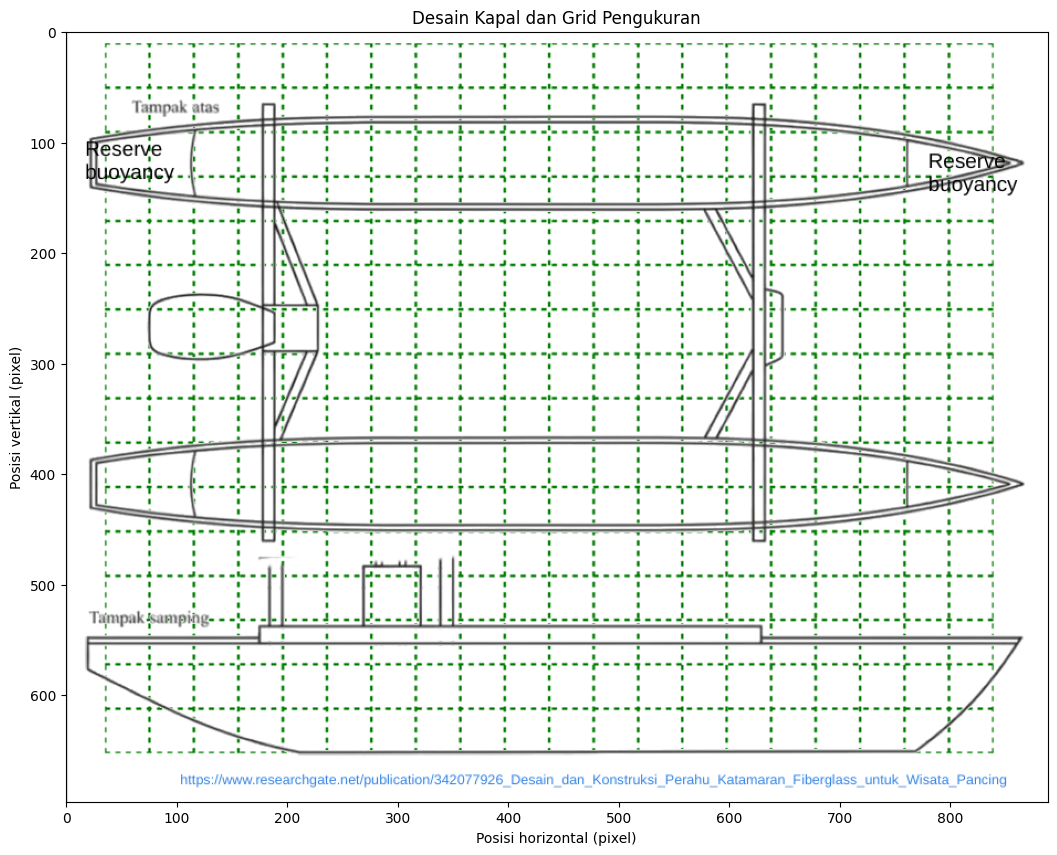

In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

# Membaca gambar
nama_file = "Kapal.png"
gambar = mpimg.imread(nama_file)

# Menampilkan gambar
plt.figure(figsize=(16, 10))
plt.imshow(gambar)
plt.title("Desain Kapal dan Grid Pengukuran")
plt.xlabel("Posisi horizontal (pixel)")
plt.ylabel("Posisi vertikal (pixel)")
plt.grid(False)

plt.show()

## **2. Menentukan Daerah Perhitungan dan Titik Penampang**

Bagian kapal yang diberi keterangan **reserve buoyancy** pada kedua ujung tidak dimasukkan ke dalam perhitungan volume. Oleh karena itu, Bagian utama lambung kapal yang dihitung dimulai dari garis grid ke-2 sampai garis grid ke-18.

Berdasarkan satu kotak grid penuh pada gambar mewakili jarak 45 cm atau 0,45 m. Titik-titik pengukuran ditentukan berdasarkan garis grid yang berada pada bagian utama lambung kapal. Jumlah titik pengukuran disesuaikan dengan jumlah interval grid yang terdapat pada daerah tersebut.

In [19]:
# Menentukan skala gambar
skala_cm = 45
skala_m = skala_cm / 100

print("Skala grid =", skala_cm, "cm")
print("Skala grid =", skala_m, "m")

Skala grid = 45 cm
Skala grid = 0.45 m


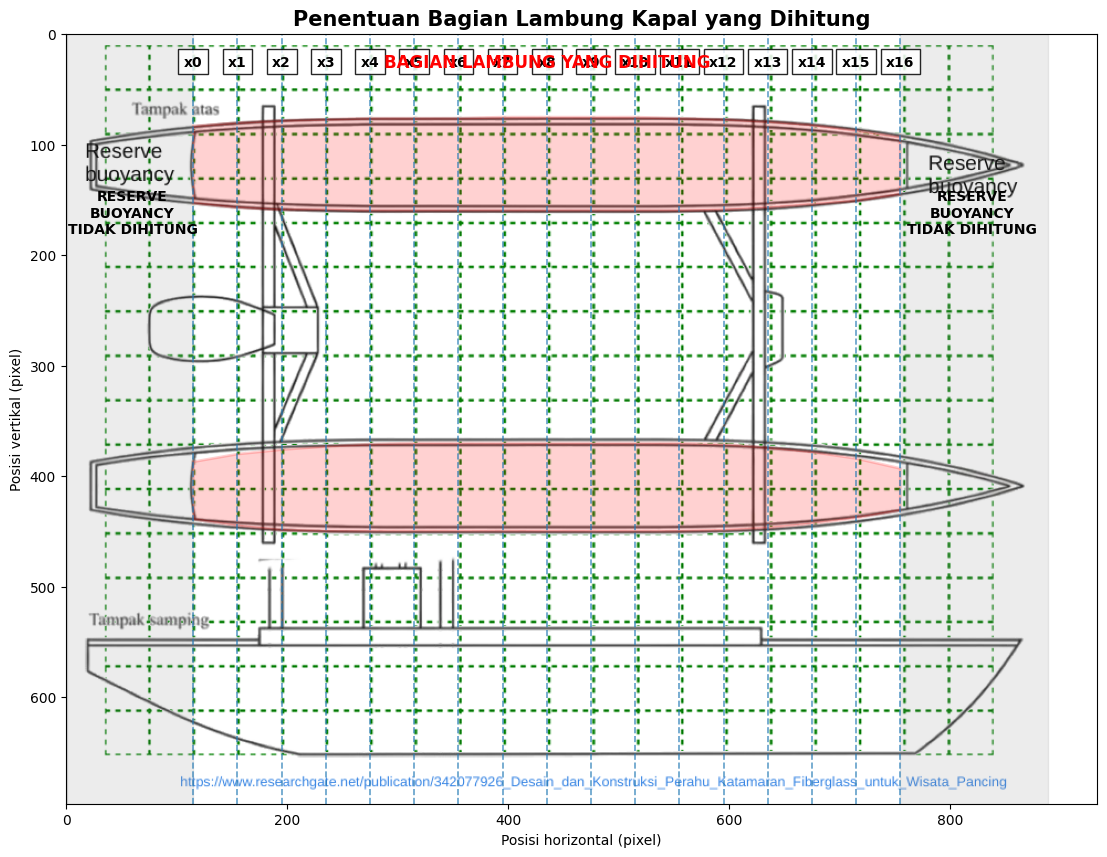

In [35]:
from matplotlib.patches import Polygon, Rectangle

plt.figure(figsize=(16, 10))
ax = plt.gca()

# Menampilkan gambar kapal asli
ax.imshow(gambar)

# TITIK PENGUKURAN
x_titik = [115 + i * 40 for i in range(17)]

for i, x_pos in enumerate(x_titik):
    ax.axvline(
        x=x_pos,
        linestyle="--",
        linewidth=1.2,
        alpha=0.7
    )

    ax.text(
        x_pos,
        25,
        f"x{i}",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            alpha=0.85,
            edgecolor="black"
        )
    )

# ARSIR LAMBUNG ATAS
lambung_atas = [
    (115, 83),
    (155, 80),
    (195, 78),
    (235, 77),
    (275, 76),
    (315, 76),
    (355, 76),
    (395, 75),
    (435, 75),
    (475, 75),
    (515, 75),
    (555, 76),
    (595, 77),
    (635, 79),
    (675, 82),
    (715, 87),
    (755, 93),
    (755, 145),
    (715, 151),
    (675, 154),
    (635, 157),
    (595, 159),
    (555, 160),
    (515, 160),
    (475, 160),
    (435, 160),
    (395, 160),
    (355, 160),
    (315, 160),
    (275, 160),
    (235, 159),
    (195, 159),
    (155, 157),
    (115, 153)
]

ax.add_patch(
    Polygon(
        lambung_atas,
        closed=True,
        facecolor="red",
        alpha=0.18,
        edgecolor="red",
        linewidth=2
    )
)

# ARSIR LAMBUNG BAWAH
lambung_bawah = [
    (115, 387),
    (155, 380),
    (195, 376),
    (235, 373),
    (275, 371),
    (315, 370),
    (355, 370),
    (395, 370),
    (435, 370),
    (475, 370),
    (515, 370),
    (555, 370),
    (595, 371),
    (635, 374),
    (675, 378),
    (715, 384),
    (755, 393),
    (755, 431),
    (715, 438),
    (675, 443),
    (635, 447),
    (595, 449),
    (555, 450),
    (515, 450),
    (475, 450),
    (435, 450),
    (395, 450),
    (355, 450),
    (315, 450),
    (275, 450),
    (235, 450),
    (195, 449),
    (155, 445),
    (115, 439)
]

ax.add_patch(
    Polygon(
        lambung_bawah,
        closed=True,
        facecolor="red",
        alpha=0.18,
        edgecolor="red",
        linewidth=2
    )
)

# RESERVE BUOYANCY
ax.axvspan(0, 115, color="gray", alpha=0.15)
ax.axvspan(755, 889, color="gray", alpha=0.15)

ax.text(
    60, 180,
    "RESERVE\nBUOYANCY\nTIDAK DIHITUNG",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    820, 180,
    "RESERVE\nBUOYANCY\nTIDAK DIHITUNG",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    435, 30,
    "BAGIAN LAMBUNG YANG DIHITUNG",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color="red"
)

ax.set_title(
    "Penentuan Bagian Lambung Kapal yang Dihitung",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Posisi horizontal (pixel)")
ax.set_ylabel("Posisi vertikal (pixel)")

plt.show()

**Menentukan jumlah interval**

Jumlah interval dihitung dari selisih antara garis grid akhir dan garis grid awal.

$$
n=18-2=16\text{ interval}
$$

Jumlah titik pengukuran dihitung dengan rumus:

$$
N=n+1
$$

Dengan memasukkan nilai jumlah interval:

$$
N=16+1=17\text{ titik}
$$

**Menentukan jarak antar titik pengukuran**

Jarak antar titik pengukuran diperoleh dari ukuran satu kotak grid, yaitu:

$$
h=45\text{ cm}=\frac{45}{100}=0{,}45\text{ m}
$$

**Menentukan panjang daerah perhitungan**

Panjang bagian lambung yang dihitung diperoleh dari jumlah interval dikalikan jarak antar titik pengukuran.

$$
L=n\times h
$$

Dengan:

- \(L\) = panjang bagian lambung yang dihitung (m).

- \(n\) = jumlah interval.
- \(h\) = jarak antar titik pengukuran (m).


Masukkan nilai yang diketahui:

$$
L=16\times0{,}45
$$

Sehingga diperoleh:

$$
\boxed{L=7{,}20\text{ m}}
$$

**Menentukan posisi relatif titik pengukuran**

Titik awal ditetapkan sebagai \(x_0=0\). Posisi setiap titik pengukuran selanjutnya dihitung menggunakan rumus:

$$
x_i=i\times h,\qquad i=0,1,2,\ldots,16
$$

Posisi titik terakhir adalah:

$$
x_{16}=16\times0{,}45=7{,}20\text{ m}
$$

Dengan demikian, terdapat 17 titik pengukuran dengan 16 interval dan panjang daerah perhitungan sebesar 7,20 m. Titik-titik ini selanjutnya digunakan sebagai acuan untuk mengukur lebar dan tinggi penampang lambung pada setiap posisi. Hasil pengukuran tersebut akan digunakan untuk menghitung luas penampang dan memperkirakan volume lambung kapal dengan metode numerik.

In [21]:
# Menghitung panjang lambung
grid_awal = 2
grid_akhir = 18

jumlah_interval = grid_akhir - grid_awal
panjang_lambung = jumlah_interval * skala_m

print("Jumlah interval =", jumlah_interval)
print("Panjang lambung =", panjang_lambung, "m")


Jumlah interval = 16
Panjang lambung = 7.2 m


## **3. Pengukuran Lebar, Tinggi, dan Luas Penampang Lambung**

Lebar lambung diukur dari tampak atas, sedangkan tinggi lambung diukur dari tampak samping pada 17 titik pengukuran, mulai dari grid ke-2 sampai grid ke-18. Ukuran pada gambar dikonversi menjadi ukuran sebenarnya menggunakan skala satu kotak grid sebesar 45 cm.

Rumus konversi ukuran gambar adalah:

$$
d=\frac{p}{p_g}\times45
$$

dengan \(d\) adalah ukuran sebenarnya (cm), \(p\) adalah ukuran objek pada gambar (piksel), dan \(p_g\) adalah panjang satu kotak grid (piksel).

Hasil pengukuran lebar dan tinggi kemudian dikonversi dari sentimeter ke meter:

$$
w_i=\frac{w_{i,\text{cm}}}{100}
\qquad
t_i=\frac{t_{i,\text{cm}}}{100}
$$

Karena penampang lambung diasumsikan berbentuk persegi panjang, luas penampang pada setiap titik dihitung dengan rumus:

$$
A_i=w_i\times t_i
$$

Sebagai contoh, pada titik pengukuran pertama, lebar lambung sebesar 79,4 cm dan tinggi sebesar 85,4 cm. Setelah dikonversi ke meter, diperoleh:

$$
w_0=\frac{79{,}4}{100}=0{,}794\text{ m}
$$

$$
t_0=\frac{85{,}4}{100}=0{,}854\text{ m}
$$

Maka luas penampangnya adalah:

$$
A_0=0{,}794\times0{,}854
$$

$$
\boxed{A_0=0{,}678076\text{ m}^2}
$$

Perhitungan yang sama dilakukan pada seluruh 17 titik pengukuran. Hasil luas penampang tersebut selanjutnya digunakan untuk menghitung volume lambung kapal.

In [33]:
# Posisi pengukuran dari grid ke-2 sampai grid ke-18
grid = np.arange(2, 19)
h = 0.45
x_m = (grid - grid[0]) * h

# Perkiraan lebar lambung dari tampak atas (cm)
lebar_cm = [
    79.4, 87.3, 92.6, 94.9, 96.1, 96.1,
    96.1, 96.1, 96.1, 96.1, 96.1, 95.8,
    93.9, 90.1, 83.5, 73.7, 59.8
]

# Perkiraan tinggi lambung dari tampak samping (cm)
tinggi_cm = [
    85.4, 101.8, 113.8, 116.4, 116.4, 116.4,
    116.4, 116.4, 116.4, 116.4, 116.4, 116.4,
    116.4, 116.4, 116.4, 116.4, 116.4
]

# Konversi ukuran dari cm ke meter
lebar_m = np.array(lebar_cm) / 100
tinggi_m = np.array(tinggi_cm) / 100

# Menghitung luas penampang persegi panjang (m²)
luas_m2 = lebar_m * tinggi_m

# Menampilkan seluruh hasil dalam satu tabel
tabel_ukur = pd.DataFrame({
    "Grid": grid,
    "Posisi x (m)": x_m,
    "Lebar (cm)": lebar_cm,
    "Tinggi (cm)": tinggi_cm,
    "Lebar (m)": lebar_m,
    "Tinggi (m)": tinggi_m,
    "Luas penampang (m²)": luas_m2
})

tabel_ukur.round(3)


,Grid,Posisi x (m),Lebar (cm),Tinggi (cm),Lebar (m),Tinggi (m),Luas penampang (m²)
0,2,0.00,79.4,85.4,0.794,0.854,0.678
1,3,0.45,87.3,101.8,0.873,1.018,0.889
2,4,0.90,92.6,113.8,0.926,1.138,1.054
3,5,1.35,94.9,116.4,0.949,1.164,1.105
4,6,1.80,96.1,116.4,0.961,1.164,1.119
5,7,2.25,96.1,116.4,0.961,1.164,1.119
6,8,2.70,96.1,116.4,0.961,1.164,1.119
7,9,3.15,96.1,116.4,0.961,1.164,1.119
8,10,3.60,96.1,116.4,0.961,1.164,1.119
9,11,4.05,96.1,116.4,0.961,1.164,1.119


## **4. Menghitung Volume Lambung Kapal**

###**a) Metode Trapesium**

Metode trapesium digunakan untuk memperkirakan volume lambung dengan menjumlahkan luas penampang pada beberapa titik sepanjang kapal.

Rumus:

$$
V=\frac{h}{2}\left[A_0+2\sum_{i=1}^{15}A_i+A_{16}\right]
$$

Keterangan:

- \(V\) = volume lambung kapal (\(\text{m}^3\)).
- \(h\) = jarak antar titik pengukuran, yaitu \(0{,}45\text{ m}\).
- \(A_0\) = luas penampang pada titik pertama.
- \(A_{16}\) = luas penampang pada titik terakhir.
- \(A_i\) = luas penampang pada titik tengah.

Luas penampang pada kedua ujung dihitung satu kali, sedangkan luas penampang pada 15 titik tengah dikalikan dua.


$$
A_0=0{,}678076\text{ m}^2
$$

Luas penampang titik terakhir :

$$
A_{16}=0{,}696072\text{ m}^2
$$

Jumlah luas penampang pada 15 titik tengah :

$$
\sum_{i=1}^{15}A_i=15{,}964046\text{ m}^2
$$

Selanjutnya, nilai tersebut dimasukkan ke dalam rumus:

$$
V=\frac{0{,}45}{2}
\left[0{,}678076+2(15{,}964046)+0{,}696072\right]
$$

$$
V=0{,}225(33{,}30224)
$$

$$
\boxed{V=7{,}493004\text{ m}^3}
$$

In [51]:

# Menghitung volume menggunakan metode trapesium
volume_trapesium = (h / 2) * (
    luas_m2[0]
    + 2 * np.sum(luas_m2[1:-1])
    + luas_m2[-1]
)

# Menghitung volume kedua lambung jika identik
volume_total = 2 * volume_trapesium

# Menampilkan hasil perhitungan
print(f"Jumlah titik pengukuran : {len(luas_m2)} titik")
print(f"Jarak antar titik       : {h:.2f} m")
print(f"Luas penampang awal     : {luas_m2[0]:.6f} m²")
print(f"Luas penampang akhir    : {luas_m2[-1]:.6f} m²")
print(f"Jumlah luas titik tengah: {np.sum(luas_m2[1:-1]):.6f} m²")

print(f"Volume satu lambung     : {volume_trapesium:.6f} m³")
print(f"Volume satu lambung     : {volume_trapesium * 1000:.2f} liter")

print(f"Volume dua lambung      : {volume_total:.6f} m³")
print(f"Volume dua lambung      : {volume_total * 1000:.2f} liter")


Jumlah titik pengukuran : 17 titik
Jarak antar titik       : 0.45 m
Luas penampang awal     : 0.678076 m²
Luas penampang akhir    : 0.696072 m²
Jumlah luas titik tengah: 15.964046 m²
Volume satu lambung     : 7.493004 m³
Volume satu lambung     : 7493.00 liter
Volume dua lambung      : 14.986008 m³
Volume dua lambung      : 14986.01 liter


### **b). Metode Simpson 1/3**

Metode Simpson 1/3 digunakan untuk memperkirakan volume lambung berdasarkan luas penampang pada 17 titik pengukuran. Karena terdapat 16 interval dengan jarak yang sama, metode ini dapat digunakan untuk menghitung perkiraan volume lambung.

Rumus yang digunakan:

$$
V=\frac{h}{3}\left[
A_0+A_{16}
+4(A_1+A_3+\cdots+A_{15})
+2(A_2+A_4+\cdots+A_{14})
\right]
$$

Luas penampang dengan indeks ganjil dikalikan 4, sedangkan indeks genap di bagian tengah dikalikan 2. Luas pada kedua ujung dijumlahkan tanpa pengali tambahan.

In [53]:

# Menghitung volume dengan metode Simpson 1/3
volume_simpson = (h / 3) * (
    luas_m2[0]
    + luas_m2[-1]
    + 4 * np.sum(luas_m2[1:-1:2])
    + 2 * np.sum(luas_m2[2:-1:2])
)

# Volume dua lambung jika keduanya identik
volume_total_simpson = 2 * volume_simpson

# Konversi m³ ke liter
volume_simpson_liter = volume_simpson * 1000
volume_total_simpson_liter = volume_total_simpson * 1000

# Menampilkan hasil
print("Jumlah titik pengukuran:", len(luas_m2))
print(f"Jumlah luas indeks ganjil: {np.sum(luas_m2[1:-1:2]):.6f} m²")
print(f"Jumlah luas indeks genap: {np.sum(luas_m2[2:-1:2]):.6f} m²")

print(f"\nVolume satu lambung: {volume_simpson:.6f} m³")
print(f"Volume satu lambung: {volume_simpson_liter:,.2f} liter")

print(f"\nVolume dua lambung: {volume_total_simpson:.6f} m³")
print(f"Volume dua lambung: {volume_total_simpson_liter:,.2f} liter")


Jumlah titik pengukuran: 17
Jumlah luas indeks ganjil: 8.370906 m²
Jumlah luas indeks genap: 7.593140 m²

Volume satu lambung: 7.506608 m³
Volume satu lambung: 7,506.61 liter

Volume dua lambung: 15.013216 m³
Volume dua lambung: 15,013.22 liter


### **c). Tabel perbandingan 2 metode & Selisih**

In [61]:
# Membuat tabel perbandingan volume
perbandingan = pd.DataFrame({
    "Metode": ["Trapesium", "Simpson 1/3"],

    "Volume satu lambung (m³)": [
        volume_trapesium,
        volume_simpson
    ],

    "Volume satu lambung (liter)": [
        volume_trapesium * 1000,
        volume_simpson * 1000
    ],

    "Volume dua lambung (m³)": [
        volume_total,
        volume_total_simpson
    ],

    "Volume dua lambung (liter)": [
        volume_total * 1000,
        volume_total_simpson * 1000
    ]
})

# Menghitung selisih volume kedua metode
selisih_m3 = abs(volume_trapesium - volume_simpson)
selisih_liter = selisih_m3 * 1000

# Menampilkan tabel perbandingan
display(perbandingan.round(2))

# Menampilkan selisih volume satu lambung
print(f"Selisih volume satu lambung : {selisih_m3:.6f} m³")
print(f"Selisih volume satu lambung : {selisih_liter:.2f} liter")



,Metode,Volume satu lambung (m³),Volume satu lambung (liter),Volume dua lambung (m³),Volume dua lambung (liter)
0,Trapesium,7.49,7493.00,14.99,14986.01
1,Simpson 1/3,7.51,7506.61,15.01,15013.22


Selisih volume satu lambung : 0.013604 m³
Selisih volume satu lambung : 13.60 liter


## **5). Visualisasi**

**a). Tampak atas dan tampak samping**

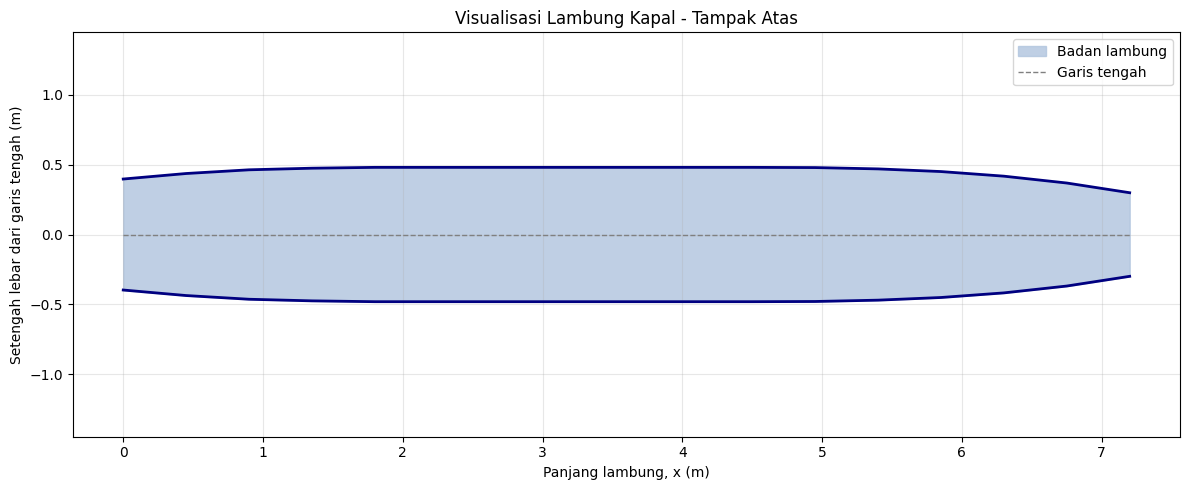

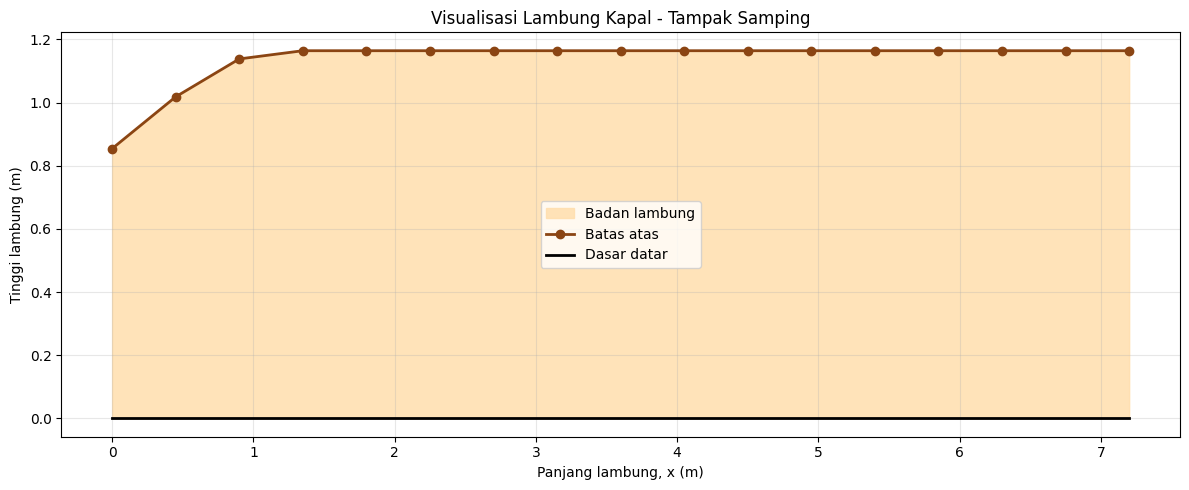

In [70]:
# 1. TAMPAK ATAS LAMBUNG

# Garis tepi kiri dan kanan berdasarkan lebar
tepi_kiri = lebar_m / 2
tepi_kanan = -lebar_m / 2

plt.figure(figsize=(12, 5))

plt.fill_between(
    x_m,
    tepi_kanan,
    tepi_kiri,
    color="lightsteelblue",
    alpha=0.8,
    label="Badan lambung"
)

plt.plot(x_m, tepi_kiri, color="navy", linewidth=2)
plt.plot(x_m, tepi_kanan, color="navy", linewidth=2)
plt.plot(x_m, np.zeros(len(x_m)), "--", color="gray",
         linewidth=1, label="Garis tengah")

plt.title("Visualisasi Lambung Kapal - Tampak Atas")
plt.xlabel("Panjang lambung, x (m)")
plt.ylabel("Setengah lebar dari garis tengah (m)")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()


# 2. TAMPAK SAMPING LAMBUNG

# Asumsi dasar lambung datar
dasar = np.zeros(len(x_m))
bagian_atas = tinggi_m

plt.figure(figsize=(12, 5))

plt.fill_between(
    x_m,
    dasar,
    bagian_atas,
    color="navajowhite",
    alpha=0.85,
    label="Badan lambung"
)

plt.plot(x_m, bagian_atas, color="saddlebrown",
         linewidth=2, marker="o", label="Batas atas")
plt.plot(x_m, dasar, color="black",
         linewidth=2, label="Dasar datar")

plt.title("Visualisasi Lambung Kapal - Tampak Samping")
plt.xlabel("Panjang lambung, x (m)")
plt.ylabel("Tinggi lambung (m)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


**b). Tampak depan — penampang melintang**

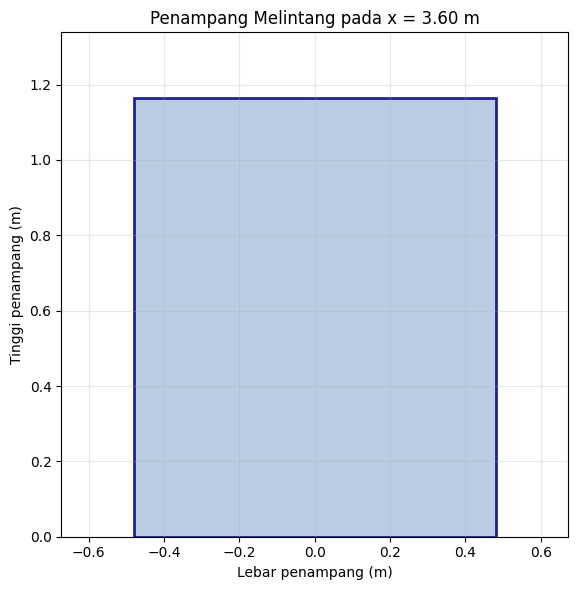

Posisi penampang : 3.60 m
Lebar penampang  : 0.961 m
Tinggi penampang : 1.164 m
Luas penampang   : 1.119 m²


In [72]:

# TAMPAK DEPAN / PENAMPANG MELINTANG

indeks_tengah = len(x_m) // 2

lebar_penampang = lebar_m[indeks_tengah]
tinggi_penampang = tinggi_m[indeks_tengah]

plt.figure(figsize=(7, 6))

plt.fill(
    [-lebar_penampang / 2,
     lebar_penampang / 2,
     lebar_penampang / 2,
     -lebar_penampang / 2],
    [0, 0, tinggi_penampang, tinggi_penampang],
    color="lightsteelblue",
    alpha=0.85,
    edgecolor="navy",
    linewidth=2
)

plt.title(
    f"Penampang Melintang pada x = {x_m[indeks_tengah]:.2f} m"
)
plt.xlabel("Lebar penampang (m)")
plt.ylabel("Tinggi penampang (m)")
plt.xlim(-lebar_penampang * 0.7, lebar_penampang * 0.7)
plt.ylim(0, tinggi_penampang * 1.15)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

print(f"Posisi penampang : {x_m[indeks_tengah]:.2f} m")
print(f"Lebar penampang  : {lebar_penampang:.3f} m")
print(f"Tinggi penampang : {tinggi_penampang:.3f} m")
print(
    f"Luas penampang   : "
    f"{lebar_penampang * tinggi_penampang:.3f} m²"
)


**c). Luas penampang sepanjang lambung**

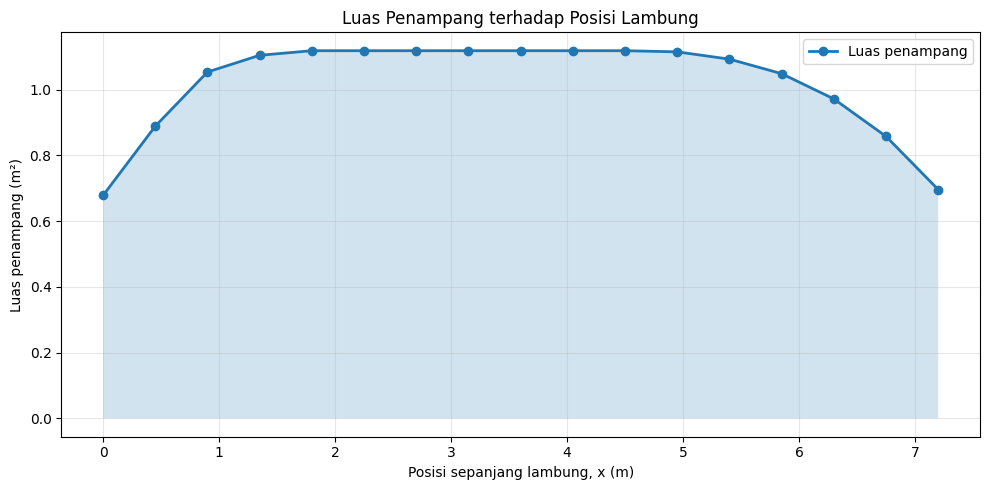

In [75]:
plt.figure()

plt.plot(
    x_m, luas_m2,
    marker="o",
    linewidth=2,
    label="Luas penampang"
)

plt.fill_between(x_m, luas_m2, alpha=0.2)

plt.title("Luas Penampang terhadap Posisi Lambung")
plt.xlabel("Posisi sepanjang lambung, x (m)")
plt.ylabel("Luas penampang (m²)")
plt.legend()
plt.tight_layout()
plt.show()


**d). Lebar dan tinggi penampang**

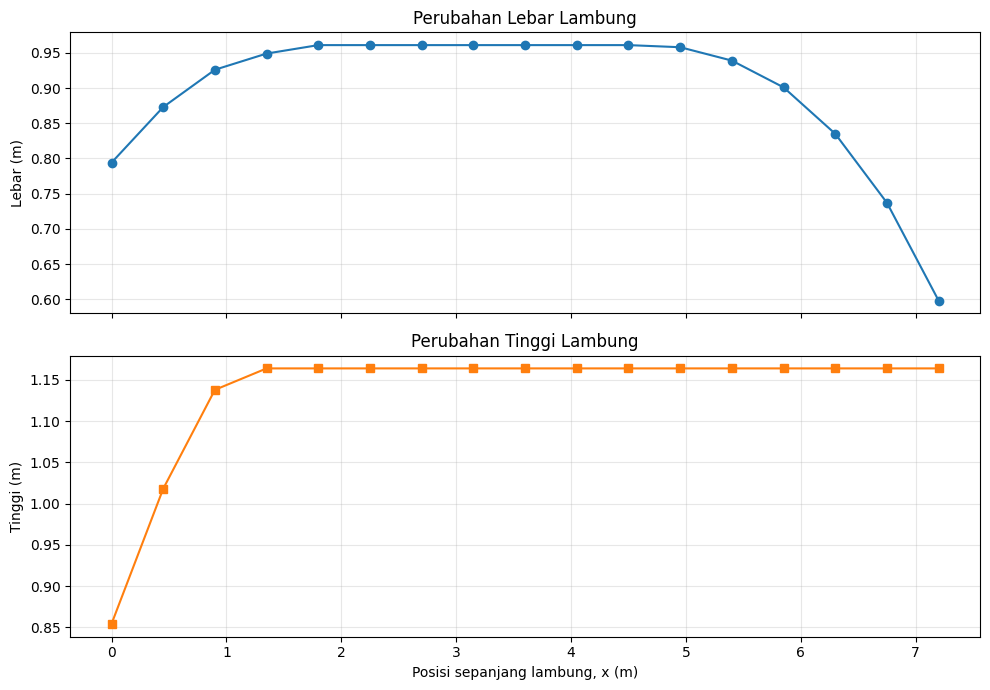

In [77]:

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax[0].plot(x_m, lebar_m, marker="o", color="tab:blue")
ax[0].set_title("Perubahan Lebar Lambung")
ax[0].set_ylabel("Lebar (m)")

ax[1].plot(x_m, tinggi_m, marker="s", color="tab:orange")
ax[1].set_title("Perubahan Tinggi Lambung")
ax[1].set_xlabel("Posisi sepanjang lambung, x (m)")
ax[1].set_ylabel("Tinggi (m)")

plt.tight_layout()
plt.show()


**e). Perbandingan volume kedua metode**

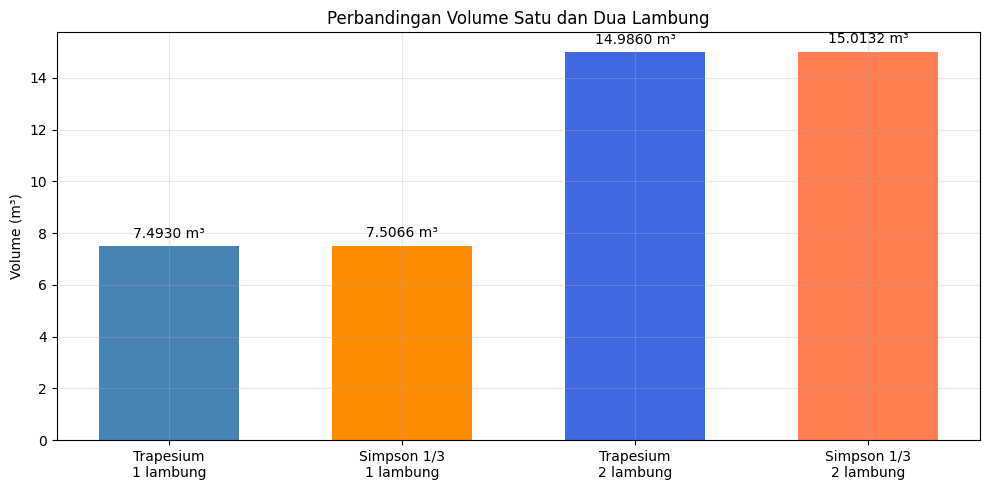

In [79]:

nama_metode = [
    "Trapesium\n1 lambung",
    "Simpson 1/3\n1 lambung",
    "Trapesium\n2 lambung",
    "Simpson 1/3\n2 lambung"
]

nilai_volume = [
    volume_trapesium,
    volume_simpson,
    volume_total,
    volume_total_simpson
]

plt.figure(figsize=(10, 5))

batang = plt.bar(
    nama_metode,
    nilai_volume,
    color=["steelblue", "darkorange", "royalblue", "coral"],
    width=0.6
)

plt.bar_label(batang, fmt="%.4f m³", padding=4)

plt.title("Perbandingan Volume Satu dan Dua Lambung")
plt.ylabel("Volume (m³)")
plt.tight_layout()
plt.show()


**f). Selisih volume**

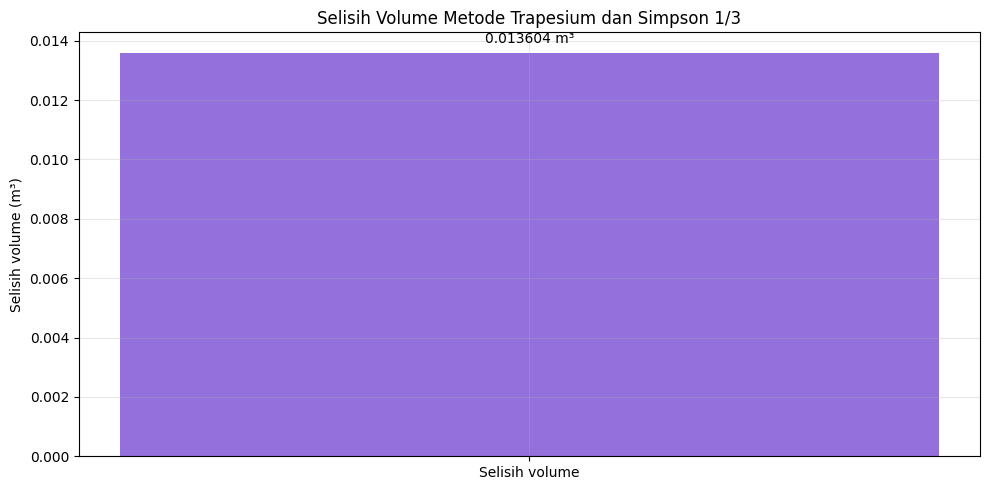

Selisih volume : 0.013604 m³
Selisih volume : 13.60 liter


In [80]:

selisih_m3 = abs(volume_trapesium - volume_simpson)
selisih_liter = selisih_m3 * 1000

plt.figure()

batang = plt.bar(
    ["Selisih volume"],
    [selisih_m3],
    color="mediumpurple",
    width=0.4
)

plt.bar_label(batang, fmt="%.6f m³", padding=5)

plt.title("Selisih Volume Metode Trapesium dan Simpson 1/3")
plt.ylabel("Selisih volume (m³)")
plt.tight_layout()
plt.show()

print(f"Selisih volume : {selisih_m3:.6f} m³")
print(f"Selisih volume : {selisih_liter:.2f} liter")


**g). Luas penampang dengan titik pengukuran**

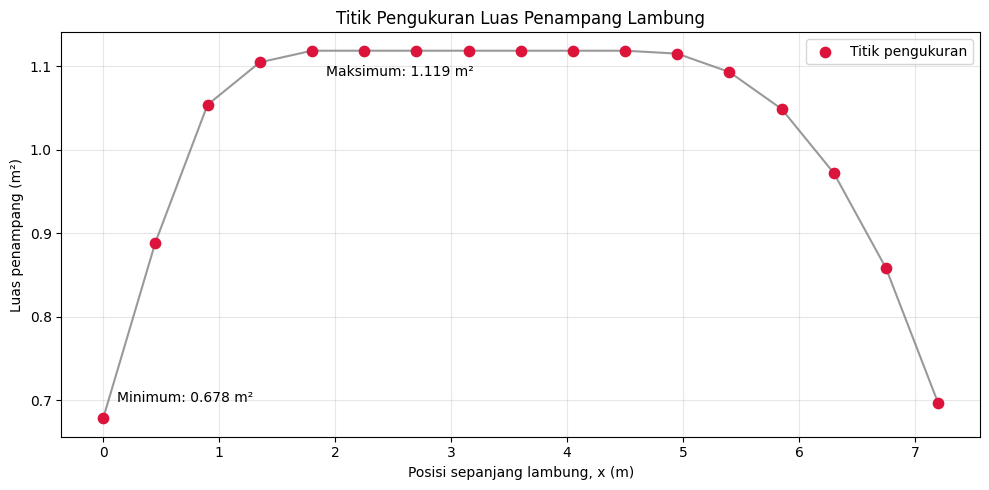

In [68]:

plt.figure()

plt.scatter(
    x_m, luas_m2,
    color="crimson",
    s=55,
    label="Titik pengukuran",
    zorder=3
)

plt.plot(x_m, luas_m2, color="gray", alpha=0.8)

idx_min = np.argmin(luas_m2)
idx_max = np.argmax(luas_m2)

plt.annotate(
    f"Minimum: {luas_m2[idx_min]:.3f} m²",
    (x_m[idx_min], luas_m2[idx_min]),
    xytext=(10, 12),
    textcoords="offset points"
)

plt.annotate(
    f"Maksimum: {luas_m2[idx_max]:.3f} m²",
    (x_m[idx_max], luas_m2[idx_max]),
    xytext=(10, -18),
    textcoords="offset points"
)

plt.title("Titik Pengukuran Luas Penampang Lambung")
plt.xlabel("Posisi sepanjang lambung, x (m)")
plt.ylabel("Luas penampang (m²)")
plt.legend()
plt.tight_layout()
plt.show()


**h). Volume kumulatif sepanjang lambung**

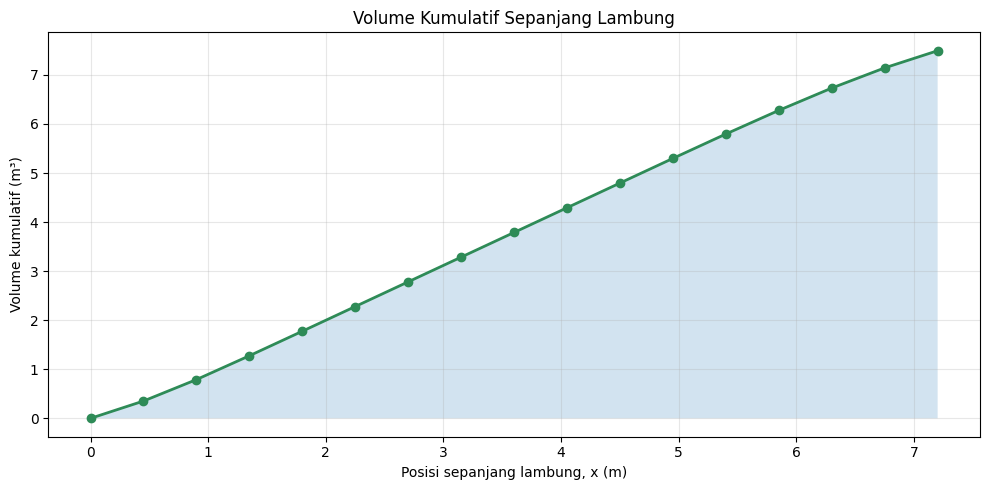

Volume akhir dari integrasi kumulatif: 7.493004 m³


In [81]:

volume_per_interval = (
    (luas_m2[:-1] + luas_m2[1:]) / 2
) * np.diff(x_m)

volume_kumulatif = np.concatenate([
    [0],
    np.cumsum(volume_per_interval)
])

plt.figure()

plt.plot(
    x_m,
    volume_kumulatif,
    marker="o",
    color="seagreen",
    linewidth=2
)

plt.fill_between(x_m, volume_kumulatif, alpha=0.2)

plt.title("Volume Kumulatif Sepanjang Lambung")
plt.xlabel("Posisi sepanjang lambung, x (m)")
plt.ylabel("Volume kumulatif (m³)")
plt.tight_layout()
plt.show()

print(
    f"Volume akhir dari integrasi kumulatif: "
    f"{volume_kumulatif[-1]:.6f} m³"
)


**KESIMPULAN**

In [89]:
# Hasil perhitungan sebelumnya
volume_trapesium = 7.4930
volume_simpson = 7.5066

# Jumlah lambung
jumlah_lambung = 2

# Menghitung volume total dua lambung identik
total_trapesium = volume_trapesium * jumlah_lambung
total_simpson = volume_simpson * jumlah_lambung

# Menghitung selisih hasil
selisih = abs(volume_simpson - volume_trapesium)
persentase_selisih = (selisih / volume_simpson) * 100

print("KESIMPULAN AKHIR PERHITUNGAN VOLUME LAMBUNG KAPAL")

print(f"""
Berdasarkan perhitungan volume lambung kapal menggunakan data
penampang yang diperoleh dari gambar grid, dengan jarak setiap
kotak sebesar 0,45 meter dan 16 interval pengamatan, diperoleh
hasil perhitungan sebagai berikut.

1. Metode Trapesium
   Volume satu lambung = {volume_trapesium:.4f} m³
   Volume dua lambung  = {total_trapesium:.4f} m³

2. Metode Simpson 1/3
   Volume satu lambung = {volume_simpson:.4f} m³
   Volume dua lambung  = {total_simpson:.4f} m³

3. Perbandingan Hasil
   Selisih volume satu lambung = {selisih:.4f} m³
   Selisih relatif             = {persentase_selisih:.4f} %

Hasil menunjukkan bahwa metode Simpson 1/3 menghasilkan estimasi
volume sedikit lebih besar daripada metode Trapesium. Perbedaan
ini terjadi karena kedua metode menggunakan pendekatan numerik
yang berbeda untuk memperkirakan volume berdasarkan data
penampang kapal.

Dalam perhitungan ini, dasar kapal diasumsikan datar tanpa keel,
penampang melintang dianggap berbentuk persegi panjang, dan
volume cadangan daya apung (reserve buoyancy) tidak diperhitungkan.
Jika kedua lambung memiliki bentuk dan ukuran identik, volume
total diperoleh dengan mengalikan volume satu lambung dengan dua.

Dengan demikian, berdasarkan angka hasil perhitungan tersebut,
estimasi volume satu lambung kapal adalah sekitar
{volume_simpson:.4f} m³ menggunakan metode Simpson 1/3, sedangkan
estimasi volume dua lambung adalah sekitar {total_simpson:.4f} m³.

Hasil ini merupakan estimasi geometris yang ketelitiannya
bergantung pada pengukuran grid, data penampang, dan asumsi
bentuk lambung yang digunakan.
""")

KESIMPULAN AKHIR PERHITUNGAN VOLUME LAMBUNG KAPAL

Berdasarkan perhitungan volume lambung kapal menggunakan data
penampang yang diperoleh dari gambar grid, dengan jarak setiap
kotak sebesar 0,45 meter dan 16 interval pengamatan, diperoleh
hasil perhitungan sebagai berikut.

1. Metode Trapesium
   Volume satu lambung = 7.4930 m³
   Volume dua lambung  = 14.9860 m³

2. Metode Simpson 1/3
   Volume satu lambung = 7.5066 m³
   Volume dua lambung  = 15.0132 m³

3. Perbandingan Hasil
   Selisih volume satu lambung = 0.0136 m³
   Selisih relatif             = 0.1812 %

Hasil menunjukkan bahwa metode Simpson 1/3 menghasilkan estimasi
volume sedikit lebih besar daripada metode Trapesium. Perbedaan
ini terjadi karena kedua metode menggunakan pendekatan numerik
yang berbeda untuk memperkirakan volume berdasarkan data
penampang kapal.

Dalam perhitungan ini, dasar kapal diasumsikan datar tanpa keel,
penampang melintang dianggap berbentuk persegi panjang, dan
volume cadangan daya apung (reserve buo